### Elastic Net Logistic Regression Baseline_Lasso_Ridge
#### Nicholas Perry

In [1]:
import sys
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from tabulate import tabulate
import matplotlib.pyplot as plt

In [2]:
import os
#print(os.getcwd())

In [3]:
#Read in data
e_cigarette_data = pd.read_csv("cleaned_data.csv")
e_cigarette_data = e_cigarette_data.dropna(subset=['E_Cig_User'])
e_cigarette_data = e_cigarette_data.drop(columns=['Unnamed: 0'])
x = e_cigarette_data.drop('E_Cig_User', axis = 1)
x_train_scaled = pd.read_csv("x_train.csv")
x_test_scaled = pd.read_csv("x_test.csv")
y_train_scaled = pd.read_csv("y_train.csv")
y_test_scaled = pd.read_csv("y_test.csv")

In [4]:
x_train_scaled = x_train_scaled.drop(columns=['Age_Category_Elderly','Age_Category_Young_Adult','Education_College_4_years_or_more_(college_graduate)',
                                             'Has_Disability','Marital_Status_Married'])

In [5]:
x_test_scaled = x_test_scaled.drop(columns=['Age_Category_Elderly','Age_Category_Young_Adult','Education_College_4_years_or_more_(college_graduate)',
                                             'Has_Disability','Marital_Status_Married'])

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [7]:
#Code Modified from https://ujangriswanto08.medium.com/building-robust-models-with-elastic-net-logistic-regression-in-python-68bdfa381cc5
# Create a pipeline to scale features and apply Elastic Net Logistic Regression
pipeline = Pipeline([  # Standardize features
    ('model', LogisticRegression(
        penalty='elasticnet',
        solver='saga',  # Required for Elastic Net
        l1_ratio=0.5,  # If set to 1, exclusively lasso. If set to 0, exclusively ridge. 0.5 balances the two
        #Setting to 0.5 to create a baseline logistic regression
        max_iter=100  # Increase iterations for convergence
    ))
])

# Fit the model
pipeline.fit(x_train_scaled, y_train_scaled)

C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Nick\my_env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=True

Confusion Matrix: [[67951    46]
 [ 4207    33]]
Precision: 0.4177215189873418
Recall: 0.007783018867924528
F1 Score: 0.015281315119240566
AUC-ROC: 0.7795921976025024


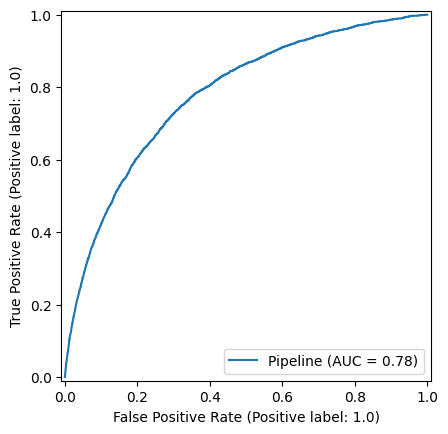

In [8]:
#Code Modified from https://ujangriswanto08.medium.com/building-robust-models-with-elastic-net-logistic-regression-in-python-68bdfa381cc5
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score,RocCurveDisplay,confusion_matrix


# Make predictions
y_pred = pipeline.predict(x_test_scaled)
y_prob = pipeline.predict_proba(x_test_scaled)[:, 1]

# Evaluate model performance
print("Confusion Matrix:",confusion_matrix(y_test_scaled, y_pred))
print("Precision:", precision_score(y_test_scaled, y_pred))
print("Recall:", recall_score(y_test_scaled, y_pred))
print("F1 Score:", f1_score(y_test_scaled, y_pred))
print("AUC-ROC:", roc_auc_score(y_test_scaled, y_prob))
RocCurveDisplay.from_estimator(pipeline,x_test_scaled, y_test_scaled)
plt.show()

In [9]:
#Code Modified from https://ujangriswanto08.medium.com/building-robust-models-with-elastic-net-logistic-regression-in-python-68bdfa381cc5
#Perform a grid search with CV to find coefficients for variables to be removed
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__l1_ratio': [0.1, 0.5, 0.7, 0.9]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='roc_auc')
grid_search.fit(x_train_scaled, y_train_scaled)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Nick\my_env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=n

Best Parameters: {'model__C': 0.01, 'model__l1_ratio': 0.1}


C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [10]:
x

,BMI,Number_of_Children,Dentist_Visit_Last_Year,Health_Insurance,Lung_Cancer_Suspected_Risk,Marijuana_Use_30_Days,Medical_Visit_Missed_Due_to_Cost,Number_of_Days_Last_Month_Poor_Health,High_Financial_Stress_Burden,Sex,...,Social_Emotional_Support,General_Health_Personal_Rating,Life_Satisfaction,Marital_Status,Sugar_Soda_Drinks_Per_Day,Sugar_Soda_Drinks_Per_Week,Sugar_Soda_Drinks_Per_Month,Non_Soda_Sugar_Drinks_Per_Day,Non_Soda_Sugar_Drinks_Per_Week,Non_Soda_Sugar_Drinks_Per_Month
0,22.49,0.0,1.0,1.0,NaN,NaN,0.0,0.0,0.0,Female,...,Always,Good,Very_satisfied,Widowed,NaN,NaN,NaN,NaN,NaN,NaN
1,25.83,0.0,1.0,1.0,NaN,NaN,0.0,NaN,0.0,Male,...,Always,Excellent,Very_satisfied,Married,NaN,NaN,NaN,NaN,NaN,NaN
2,22.53,0.0,0.0,1.0,NaN,NaN,1.0,1.0,0.0,Male,...,Usually,Very_good,Very_satisfied,Member_of_unmarried_couple,NaN,NaN,NaN,NaN,NaN,NaN
3,25.09,0.0,1.0,1.0,NaN,NaN,0.0,NaN,0.0,Male,...,Always,Excellent,Very_satisfied,Married,NaN,NaN,NaN,NaN,NaN,NaN
4,19.77,0.0,1.0,1.0,0.0,NaN,0.0,NaN,0.0,Male,...,Rarely,Good,Satisfied,Never_Married,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457663,24.66,2.0,0.0,0.0,NaN,0.0,0.0,0.0,1.0,Male,...,Sometimes,Very_good,Very_satisfied,Never_Married,NaN,NaN,NaN,NaN,NaN,NaN
457664,29.86,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Male,...,Unknown,Poor,Unknown,Widowed,NaN,NaN,NaN,NaN,NaN,NaN
457666,20.66,0.0,1.0,0.0,NaN,0.0,0.0,0.0,0.0,Male,...,Sometimes,Fair,Satisfied,Never_Married,NaN,NaN,NaN,NaN,NaN,NaN
457667,24.37,0.0,0.0,1.0,NaN,0.0,0.0,NaN,0.0,Male,...,Always,Good,Satisfied,Never_Married,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#Code Modified from https://ujangriswanto08.medium.com/building-robust-models-with-elastic-net-logistic-regression-in-python-68bdfa381cc5
#These are the variables to be removed
# Get feature coefficients
coefficients = grid_search.best_estimator_.named_steps['model'].coef_[0]
feature_importance = pd.DataFrame({
    'Feature': x_train_scaled.columns,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(feature_importance.head())

                                              Feature  Coefficient
95                       Marital_Status_Never_Married     0.367410
71    Education_Grade_12_or_GED_(high_school_graduate     0.364525
70  Education_College_1-3_years_(some_college_or_t...     0.300236
94          Marital_Status_Member_of_unmarried_couple     0.219654
20                     Days_Poor_Mental_Health_0_Days    -0.209840


Ridge

In [9]:
#Code Modified from https://ujangriswanto08.medium.com/building-robust-models-with-elastic-net-logistic-regression-in-python-68bdfa381cc5
# Create a pipeline to scale features and apply Elastic Net Logistic Regression
pipeline = Pipeline([  # Standardize features
    ('model', LogisticRegression(
        penalty='elasticnet',
        solver='saga',  # Required for Elastic Net
        l1_ratio=0,  # If set to 1, exclusively lasso. If set to 0, exclusively ridge. 0.5 balances the two
        #Setting to 0.5 to create a baseline logistic regression
        max_iter=100  # Increase iterations for convergence
    ))
])

# Fit the model
pipeline.fit(x_train_scaled, y_train_scaled)

C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Nick\my_env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSp

Confusion Matrix: [[67951    46]
 [ 4207    33]]
Precision: 0.4177215189873418
Recall: 0.007783018867924528
F1 Score: 0.015281315119240566
AUC-ROC: 0.7795930716699211


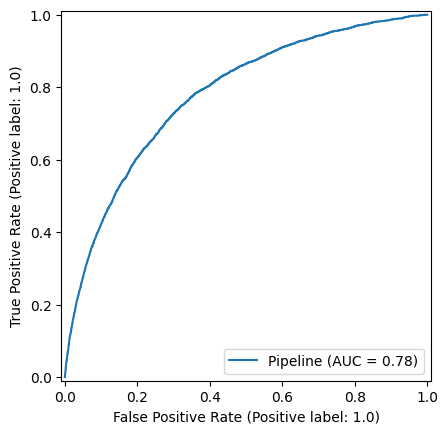

In [10]:
#Code Modified from https://ujangriswanto08.medium.com/building-robust-models-with-elastic-net-logistic-regression-in-python-68bdfa381cc5
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score,RocCurveDisplay


# Make predictions
y_pred = pipeline.predict(x_test_scaled)
y_prob = pipeline.predict_proba(x_test_scaled)[:, 1]

# Evaluate model performance
print("Confusion Matrix:",confusion_matrix(y_test_scaled, y_pred))
print("Precision:", precision_score(y_test_scaled, y_pred))
print("Recall:", recall_score(y_test_scaled, y_pred))
print("F1 Score:", f1_score(y_test_scaled, y_pred))
print("AUC-ROC:", roc_auc_score(y_test_scaled, y_prob))
RocCurveDisplay.from_estimator(pipeline,x_test_scaled, y_test_scaled)
plt.show()

In [14]:
#Code Modified from https://ujangriswanto08.medium.com/building-robust-models-with-elastic-net-logistic-regression-in-python-68bdfa381cc5
#Perform a grid search with CV to find coefficients for variables to be removed
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__l1_ratio': [0.1, 0.5, 0.7, 0.9]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='roc_auc')
grid_search.fit(x_train_scaled, y_train_scaled)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Nick\my_env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=n

Best Parameters: {'model__C': 0.01, 'model__l1_ratio': 0.1}


C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [15]:
#Code Modified from https://ujangriswanto08.medium.com/building-robust-models-with-elastic-net-logistic-regression-in-python-68bdfa381cc5
#These are the variables to be removed
# Get feature coefficients
coefficients = grid_search.best_estimator_.named_steps['model'].coef_[0]
feature_importance = pd.DataFrame({
    'Feature': x_train_scaled.columns,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(feature_importance.head())

                                              Feature  Coefficient
95                       Marital_Status_Never_Married     0.367410
71    Education_Grade_12_or_GED_(high_school_graduate     0.364525
70  Education_College_1-3_years_(some_college_or_t...     0.300236
94          Marital_Status_Member_of_unmarried_couple     0.219654
20                     Days_Poor_Mental_Health_0_Days    -0.209840


Lasso

In [11]:
#Code Modified from https://ujangriswanto08.medium.com/building-robust-models-with-elastic-net-logistic-regression-in-python-68bdfa381cc5
# Create a pipeline to scale features and apply Elastic Net Logistic Regression
pipeline = Pipeline([  # Standardize features
    ('model', LogisticRegression(
        penalty='elasticnet',
        solver='saga',  # Required for Elastic Net
        l1_ratio=1,  # If set to 1, exclusively lasso. If set to 0, exclusively ridge. 0.5 balances the two
        #Setting to 0.5 to create a baseline logistic regression
        max_iter=100  # Increase iterations for convergence
    ))
])

# Fit the model
pipeline.fit(x_train_scaled, y_train_scaled)

C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Nick\my_env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSp

Confusion Matrix: [[67951    46]
 [ 4207    33]]
Precision: 0.4177215189873418
Recall: 0.007783018867924528
F1 Score: 0.015281315119240566
AUC-ROC: 0.7795921733228519


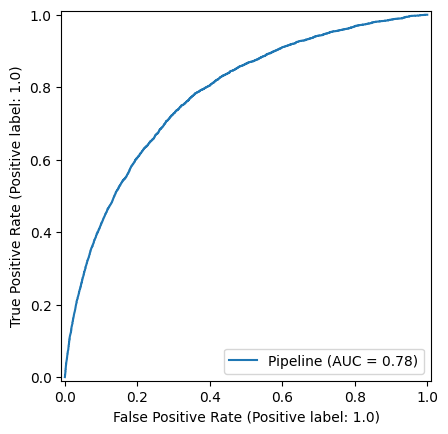

In [12]:
#Code Modified from https://ujangriswanto08.medium.com/building-robust-models-with-elastic-net-logistic-regression-in-python-68bdfa381cc5
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score,RocCurveDisplay


# Make predictions
y_pred = pipeline.predict(x_test_scaled)
y_prob = pipeline.predict_proba(x_test_scaled)[:, 1]

# Evaluate model performance
print("Confusion Matrix:",confusion_matrix(y_test_scaled, y_pred))
print("Precision:", precision_score(y_test_scaled, y_pred))
print("Recall:", recall_score(y_test_scaled, y_pred))
print("F1 Score:", f1_score(y_test_scaled, y_pred))
print("AUC-ROC:", roc_auc_score(y_test_scaled, y_prob))
RocCurveDisplay.from_estimator(pipeline,x_test_scaled, y_test_scaled)
plt.show()

In [18]:
#Code Modified from https://ujangriswanto08.medium.com/building-robust-models-with-elastic-net-logistic-regression-in-python-68bdfa381cc5
#Perform a grid search with CV to find coefficients for variables to be removed
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__l1_ratio': [0.1, 0.5, 0.7, 0.9]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='roc_auc')
grid_search.fit(x_train_scaled, y_train_scaled)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Nick\my_env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=n

Best Parameters: {'model__C': 0.01, 'model__l1_ratio': 0.1}


C:\Users\Nick\my_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [19]:
#Code Modified from https://ujangriswanto08.medium.com/building-robust-models-with-elastic-net-logistic-regression-in-python-68bdfa381cc5
#These are the variables to be removed
# Get feature coefficients
coefficients = grid_search.best_estimator_.named_steps['model'].coef_[0]
feature_importance = pd.DataFrame({
    'Feature': x_train_scaled.columns,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(feature_importance.head())

                                              Feature  Coefficient
95                       Marital_Status_Never_Married     0.367410
71    Education_Grade_12_or_GED_(high_school_graduate     0.364525
70  Education_College_1-3_years_(some_college_or_t...     0.300236
94          Marital_Status_Member_of_unmarried_couple     0.219654
20                     Days_Poor_Mental_Health_0_Days    -0.209840
